# Dynamic Pricing Engine for Urban Parking Lots

Forecasts next-day parking demand and sets prices proactively — reducing overcrowding at full lots and increasing utilization at underused ones.

**Part A** — Data loading & cleaning

**Part B** — Pathway streaming pipeline, 4 rule-based pricing models

**Part C** — XGBoost per-lot demand forecasting with R²/MAE/MAPE evaluation

**Part D** — Haversine-based geolocation rerouting

**Part E** — Hybrid pricing system (ML + rules) and final dashboards

## Setup

In [1]:
!pip install pathway bokeh panel xgboost --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from datetime import datetime
import pathway as pw
import bokeh.plotting
import panel as pn
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
from math import radians, sin, cos, sqrt, atan2

---
## Part A — Data Loading & Cleaning

In [3]:
github_url = "https://raw.githubusercontent.com/Krishtiy/final-project-data-anlytics/refs/heads/main/dataset%20(6).csv"
df = pd.read_csv(github_url)
df.columns = df.columns.str.strip()
df.shape

(18368, 12)

In [4]:
grouped_datasets = {group: data for group, data in df.groupby('SystemCodeNumber')}
df['SystemCodeNumber'].unique()

<ArrowStringArray>
[     'BHMBCCMKT01',      'BHMBCCTHL01',      'BHMEURBRD01',
      'BHMMBMMBX01',      'BHMNCPHST01',      'BHMNCPNST01',
     'Broad Street', 'Others-CCCPS105a', 'Others-CCCPS119a',
 'Others-CCCPS135a',  'Others-CCCPS202',    'Others-CCCPS8',
   'Others-CCCPS98',         'Shopping']
Length: 14, dtype: str

In [5]:
print(df['SystemCodeNumber'].unique())
print(df.shape)

<ArrowStringArray>
[     'BHMBCCMKT01',      'BHMBCCTHL01',      'BHMEURBRD01',
      'BHMMBMMBX01',      'BHMNCPHST01',      'BHMNCPNST01',
     'Broad Street', 'Others-CCCPS105a', 'Others-CCCPS119a',
 'Others-CCCPS135a',  'Others-CCCPS202',    'Others-CCCPS8',
   'Others-CCCPS98',         'Shopping']
Length: 14, dtype: str
(18368, 12)


In [6]:
df['TrafficConditionNearby'].unique()

<ArrowStringArray>
['low', 'high', 'average']
Length: 3, dtype: str

In [7]:
df['Timestamp'] = pd.to_datetime(
    df['LastUpdatedDate'] + ' ' + df['LastUpdatedTime'],
    format='%d-%m-%Y %H:%M:%S'
)
df = df.sort_values('Timestamp').reset_index(drop=True)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [8]:
df_clean = df[[
    "Timestamp", "SystemCodeNumber", "Occupancy", "Capacity",
    "QueueLength", "TrafficConditionNearby", "IsSpecialDay",
    "VehicleType", "Latitude", "Longitude"
]]

df_clean.to_csv("parking_stream.csv", index=False)
print(f"Saved {len(df_clean)} rows across {df_clean['SystemCodeNumber'].nunique()} lots")

Saved 18368 rows across 14 lots


---
## Part B  Pathway Streaming Pipeline & 4 Rule-Based Pricing Models

Data is replayed as a stream through Pathway and aggregated with **daily tumbling windows**, so each model reacts to a full day of activity per lot.

In [9]:
class ParkingSchema(pw.Schema):
    Timestamp: str
    SystemCodeNumber: str
    Occupancy: int
    Capacity: int
    QueueLength: int
    TrafficConditionNearby: str
    IsSpecialDay: int
    VehicleType: str
    Latitude: float
    Longitude: float

In [10]:
data = pw.demo.replay_csv("parking_stream.csv", schema=ParkingSchema, input_rate=100)

In [11]:
fmt = "%Y-%m-%d %H:%M:%S"

data_with_time = data.with_columns(
    t=data.Timestamp.dt.strptime(fmt),
    day=data.Timestamp.dt.strptime(fmt).dt.strftime("%Y-%m-%dT00:00:00")
)

### Model 1  Baseline Linear

Price increases with the daily occupancy swing (max minus min occupancy that day).

`Price = $10 + 5 × (occ_max - occ_min) / capacity`

In [12]:
import datetime  # re-import: 'from datetime import datetime' above shadows the module

base_price = 10
alpha = 5

delta_window1 = (
    data_with_time.windowby(
        pw.this.t,
        instance=pw.this.day,
        window=pw.temporal.tumbling(datetime.timedelta(days=1)),
        behavior=pw.temporal.exactly_once_behavior()
    )
    .reduce(
        t=pw.this._pw_window_end,
        occ_max=pw.reducers.max(pw.this.Occupancy),
        occ_min=pw.reducers.min(pw.this.Occupancy),
        cap=pw.reducers.max(pw.this.Capacity),
    )
    .with_columns(
        price=base_price + alpha * (pw.this.occ_max - pw.this.occ_min) / pw.this.cap,
    )
)
print("Model 1 defined")

Model 1 defined


### Model 2 Demand-Based

Combines 5 signals into a weighted demand score.

`Demand = 0.5×(Occ/Cap) + 0.3×QueueLength + 0.4×IsSpecialDay + VehicleWeight + TrafficWeight`

`Price = $10 × (1 + 0.8 × Demand / 5)`

In [13]:
base_price = 10
alpha, beta, delta_coef = 0.5, 0.3, 0.4
lambda_ = 0.8

def get_traffic_weight(t: str) -> float:
    return float({"low": 0.6, "average": 1.0, "high": 1.4}.get(t, 1.0))

def get_vehicle_weight(v: str) -> float:
    return float({"car": 1.0, "bike": 0.6, "truck": 1.4, "cycle": 0.5}.get(v, 1.0))

def compute_price(
    occ_max: int,
    occ_min: int,
    cap: int,
    queue: int,
    special: int,
    vehicle: float,
    traffic: float
) -> float:
    return float(base_price) * (
        1.0 + lambda_ * (
            alpha * float(occ_max - occ_min) / float(cap)
            + beta * float(queue)
            + delta_coef * float(special)
            + vehicle
            + traffic
        ) / 5.0
    )

delta_window2 = (
    data_with_time.windowby(
        pw.this.t,
        instance=pw.this.day,
        window=pw.temporal.tumbling(datetime.timedelta(days=1)),
        behavior=pw.temporal.exactly_once_behavior()
    )
    .reduce(
        t=pw.this._pw_window_end,
        occ_max=pw.reducers.max(pw.this.Occupancy),
        occ_min=pw.reducers.min(pw.this.Occupancy),
        cap=pw.reducers.max(pw.this.Capacity),
        IsSpecialDay=pw.reducers.max(pw.this.IsSpecialDay),
        queue=pw.reducers.max(pw.this.QueueLength),
        traffic_str=pw.reducers.any(pw.this.TrafficConditionNearby),
        vehicle_str=pw.reducers.any(pw.this.VehicleType),
    )
    .with_columns(
        traffic=pw.apply(get_traffic_weight, pw.this.traffic_str),
        vehicle_weight=pw.apply(get_vehicle_weight, pw.this.vehicle_str),
    )
    .with_columns(
        price=pw.apply(
            compute_price,
            pw.this.occ_max,
            pw.this.occ_min,
            pw.this.cap,
            pw.this.queue,
            pw.this.IsSpecialDay,
            pw.this.vehicle_weight,
            pw.this.traffic,
        )
    )
)
print("Model 2 defined")

Model 2 defined


### Model 3  Surge / Discount

Clear thresholds with a hard price clamp.

- Occupancy > 80% → 1.5x surge multiplier
- Occupancy < 30% → 0.8x discount multiplier
- `Final Price = clamp($5, computed_price, $20)`

In [14]:
base_price = 10
surge_factor = 1.5
discount_factor = 0.8
threshold_high = 0.8
threshold_low = 0.3

delta_window3 = (
    data_with_time.windowby(
        pw.this.t,
        instance=pw.this.day,
        window=pw.temporal.tumbling(datetime.timedelta(days=1)),
        behavior=pw.temporal.exactly_once_behavior()
    )
    .reduce(
        t=pw.this._pw_window_end,
        occ_max=pw.reducers.max(pw.this.Occupancy),
        occ_min=pw.reducers.min(pw.this.Occupancy),
        cap=pw.reducers.max(pw.this.Capacity),
        IsSpecialDay=pw.reducers.max(pw.this.IsSpecialDay),
        queue=pw.reducers.max(pw.this.QueueLength),
        traffic_str=pw.reducers.any(pw.this.TrafficConditionNearby),
        vehicle_str=pw.reducers.any(pw.this.VehicleType),
    )
    .with_columns(
        occupancy_rate=pw.this.occ_max / pw.this.cap,
        traffic=pw.apply(
            lambda t: {"low": 0.6, "average": 1.0, "high": 1.4}.get(t, 1.0),
            pw.this.traffic_str
        ),
        vehicle_weight=pw.apply(
            lambda v: {"car": 1.0, "bike": 0.6, "truck": 1.4, "cycle": 0.5}.get(v, 1.0),
            pw.this.vehicle_str
        ),
    )
    .with_columns(
        price_multiplier=pw.apply(
            lambda rate: surge_factor if rate > threshold_high
                         else (discount_factor if rate < threshold_low else 1.0),
            pw.this.occupancy_rate
        )
    )
    .with_columns(
        price=pw.apply(
            lambda base, multiplier, special, traffic, vehicle, queue: max(5.0, min(
                base * multiplier
                * (1.2 if special else 1.0)
                * traffic
                * vehicle
                * (1 + 0.05 * queue),
                20.0
            )),
            base_price,
            pw.this.price_multiplier,
            pw.this.IsSpecialDay,
            pw.this.traffic,
            pw.this.vehicle_weight,
            pw.this.queue,
        )
    )
)
print("Model 3 defined")

Model 3 defined


### Model 4  Competitive

Processes all 14 lots simultaneously. Lots above 85% occupancy raise prices slightly; lots below 30% undercut the market. Rerouting alerts trigger at 90% occupancy.

In [15]:
import math

lot_daily = (
    data_with_time.windowby(
        pw.this.t,
        instance=pw.this.SystemCodeNumber,
        window=pw.temporal.tumbling(datetime.timedelta(days=1)),
        behavior=pw.temporal.exactly_once_behavior()
    )
    .reduce(
        t=pw.this._pw_window_end,
        lot=pw.reducers.any(pw.this.SystemCodeNumber),
        lat=pw.reducers.any(pw.this.Latitude),
        lon=pw.reducers.any(pw.this.Longitude),
        occ_max=pw.reducers.max(pw.this.Occupancy),
        occ_min=pw.reducers.min(pw.this.Occupancy),
        cap=pw.reducers.max(pw.this.Capacity),
        queue=pw.reducers.max(pw.this.QueueLength),
        IsSpecialDay=pw.reducers.max(pw.this.IsSpecialDay),
        traffic_str=pw.reducers.any(pw.this.TrafficConditionNearby),
        vehicle_str=pw.reducers.any(pw.this.VehicleType),
    )
    .with_columns(
        occupancy_rate=pw.this.occ_max / pw.this.cap,
        traffic=pw.apply(get_traffic_weight, pw.this.traffic_str),
        vehicle_weight=pw.apply(get_vehicle_weight, pw.this.vehicle_str),
    )
    .with_columns(
        base_demand_price=pw.apply(
            compute_price,
            pw.this.occ_max, pw.this.occ_min, pw.this.cap,
            pw.this.queue, pw.this.IsSpecialDay,
            pw.this.vehicle_weight, pw.this.traffic,
        )
    )
)

def competitive_price(base_price: float, occupancy_rate: float, lat: float, lon: float) -> float:
    if occupancy_rate > 0.85:
        multiplier = 1.1
    elif occupancy_rate < 0.3:
        multiplier = 0.85
    else:
        multiplier = 1.0
    return float(max(5.0, min(base_price * multiplier, 20.0)))

def reroute_flag(occupancy_rate: float) -> str:
    if occupancy_rate > 0.9:
        return "REROUTE_SUGGESTED"
    elif occupancy_rate > 0.75:
        return "HIGH_DEMAND"
    else:
        return "NORMAL"

delta_competitive = (
    lot_daily
    .with_columns(
        price=pw.apply(
            competitive_price,
            pw.this.base_demand_price,
            pw.this.occupancy_rate,
            pw.this.lat,
            pw.this.lon,
        ),
        reroute_status=pw.apply(reroute_flag, pw.this.occupancy_rate),
    )
)
print("delta_competitive (Model 4) defined successfully")

delta_competitive (Model 4) defined successfully


### Run the streaming pipeline and write outputs

In [16]:
pn.extension()

pw.io.csv.write(delta_window1.select(pw.this.t, pw.this.price), "out_model1.csv")
pw.io.csv.write(delta_window2.select(pw.this.t, pw.this.price), "out_model2.csv")
pw.io.csv.write(delta_window3.select(pw.this.t, pw.this.price), "out_model3.csv")
pw.io.csv.write(
    delta_competitive.select(
        pw.this.t, pw.this.lot, pw.this.price,
        pw.this.occupancy_rate, pw.this.reroute_status
    ),
    "out_competitive.csv"
)

/usr/local/lib/python3.12/dist-packages/beartype/_util/hint/pep/utilpeptest.py:311: BeartypeDecorHintPep585DeprecationWarning: PEP 484 type hint typing.Iterable[pathway.internals.expression.ColumnReference] deprecated by PEP 585. This hint is scheduled for removal in the first Python version released after October 5th, 2025. To resolve this, import this hint from "beartype.typing" rather than "typing". For further commentary and alternatives, see also:
    https://beartype.readthedocs.io/en/latest/api_roar/#pep-585-deprecations
  warn(


In [17]:
# Write rerouting alerts (rule-based, current-occupancy version) to a CSV for review
pw.io.csv.write(
    delta_competitive.filter(pw.this.reroute_status != "NORMAL")
    .select(
        pw.this.t,
        pw.this.lot,
        pw.this.occupancy_rate,
        pw.this.price,
        pw.this.reroute_status,
    ),
    "rerouting_alerts.csv"
)
print("Rerouting alerts will be written to rerouting_alerts.csv during pw.run()")

Rerouting alerts will be written to rerouting_alerts.csv during pw.run()


In [18]:
pw.run()

Output()

In [19]:
import os

files = ["out_model1.csv", "out_model2.csv", "out_model3.csv", "out_competitive.csv"]
for f in files:
    if os.path.exists(f):
        df_check = pd.read_csv(f)
        print(f"✓ {f} — {len(df_check)} rows")
        print(df_check.head(3))
        print()
    else:
        print(f"✗ {f} — NOT FOUND")

✓ out_model1.csv — 73 rows
                               t      price           time  diff
0  2016-10-05T00:00:00.000000000  14.107649  1783540827536     1
1  2016-10-06T00:00:00.000000000  14.067731  1783540830156     1
2  2016-10-07T00:00:00.000000000  13.964718  1783540832786     1

✓ out_model2.csv — 73 rows
                               t      price           time  diff
0  2016-10-05T00:00:00.000000000  18.497224  1783540827536     1
1  2016-10-06T00:00:00.000000000  18.490837  1783540830156     1
2  2016-10-07T00:00:00.000000000  19.754355  1783540832786     1

✓ out_model3.csv — 73 rows
                               t  price           time  diff
0  2016-10-05T00:00:00.000000000  13.95  1783540827536     1
1  2016-10-06T00:00:00.000000000  13.95  1783540830156     1
2  2016-10-07T00:00:00.000000000  20.00  1783540832786     1

✓ out_competitive.csv — 1022 rows
                               t               lot      price  occupancy_rate  \
0  2016-10-05T00:00:00.000000000     

### Static dashboard — 4 pricing models

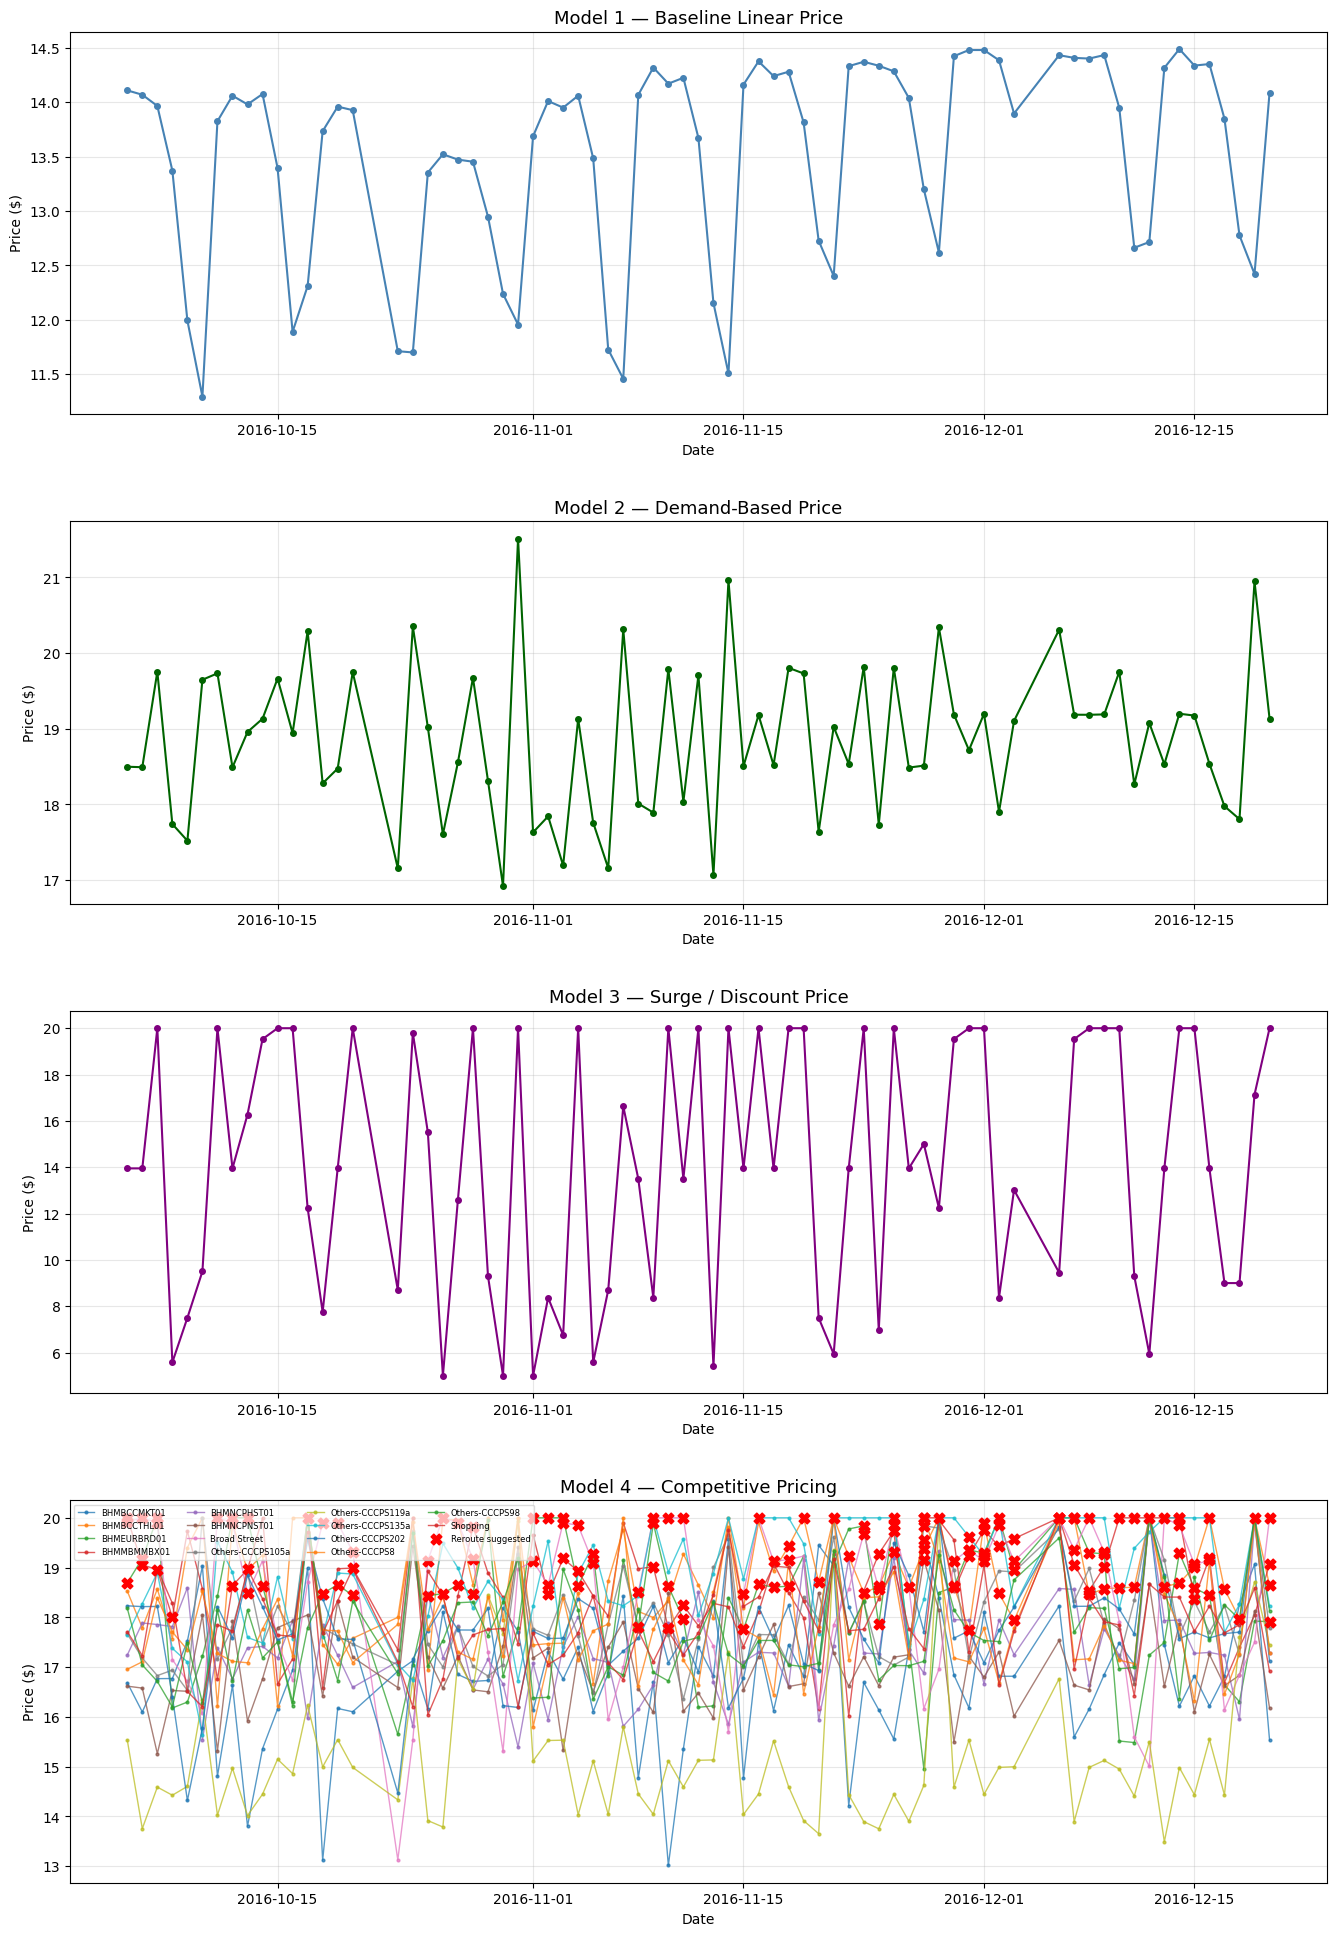

Saved to pricing_dashboard.png


In [20]:
fig, axes = plt.subplots(4, 1, figsize=(14, 20))
titles = [
    ("out_model1.csv", "Model 1 — Baseline Linear Price", "steelblue"),
    ("out_model2.csv", "Model 2 — Demand-Based Price", "darkgreen"),
    ("out_model3.csv", "Model 3 — Surge / Discount Price", "purple"),
    ("out_competitive.csv", "Model 4 — Competitive Pricing", "firebrick"),
]

for ax, (fname, title, color) in zip(axes, titles):
    df_out = pd.read_csv(fname)
    df_out['t'] = pd.to_datetime(df_out['t'])
    df_out = df_out.sort_values('t')

    if 'lot' in df_out.columns:
        for lot, grp in df_out.groupby('lot'):
            ax.plot(grp['t'], grp['price'], marker='o', markersize=2,
                    linewidth=1, label=lot, alpha=0.75)
        if 'reroute_status' in df_out.columns:
            reroute = df_out[df_out['reroute_status'] == 'REROUTE_SUGGESTED']
            if len(reroute) > 0:
                ax.scatter(reroute['t'], reroute['price'],
                           color='red', s=60, zorder=5,
                           label='Reroute suggested', marker='X')
        ax.legend(fontsize=6, ncol=4, loc='upper left', framealpha=0.7)
    else:
        ax.plot(df_out['t'], df_out['price'], color=color, marker='o', markersize=4)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price ($)")
    ax.grid(True, alpha=0.3)

plt.tight_layout(pad=3)
plt.savefig("pricing_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to pricing_dashboard.png")

---
## Part C —XGBoost Demand Forecasting

**Goal:** predict *tomorrow's* peak occupancy per lot, so prices can be set proactively rather than reactively.

We aggregate to one row per lot per day, engineer 16 features, and train **one XGBoost model per lot** a single pooled model across all 14 lots underperforms (R²≈0.45) because each lot has a different capacity, location, and demand pattern that confuses a shared model.

In [21]:
daily = df.groupby(['SystemCodeNumber', df['Timestamp'].dt.date]).agg(
    peak_occupancy=('Occupancy', 'max'),
    avg_occupancy=('Occupancy', 'mean'),
    min_occupancy=('Occupancy', 'min'),
    capacity=('Capacity', 'max'),
    queue_max=('QueueLength', 'max'),
    queue_avg=('QueueLength', 'mean'),
    is_special_day=('IsSpecialDay', 'max'),
    lat=('Latitude', 'first'),
    lon=('Longitude', 'first'),
).reset_index().rename(columns={'Timestamp': 'Date'})

traffic_map = {"low": 0.6, "average": 1.0, "high": 1.4}
vehicle_map = {"car": 1.0, "bike": 0.6, "truck": 1.4, "cycle": 0.5}
df['traffic_weight'] = df['TrafficConditionNearby'].map(traffic_map).fillna(1.0)
df['vehicle_weight'] = df['VehicleType'].map(vehicle_map).fillna(1.0)
tw = df.groupby(['SystemCodeNumber', df['Timestamp'].dt.date])[['traffic_weight','vehicle_weight']].mean()
tw.index.set_names(['SystemCodeNumber','Date'], inplace=True)
daily = daily.merge(
    tw.reset_index().rename(columns={'traffic_weight':'traffic_avg','vehicle_weight':'vehicle_avg'}),
    on=['SystemCodeNumber','Date']
)

daily['occupancy_rate'] = daily['peak_occupancy'] / daily['capacity']
daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.sort_values(['SystemCodeNumber', 'Date']).reset_index(drop=True)
daily.head()

,SystemCodeNumber,Date,peak_occupancy,avg_occupancy,min_occupancy,capacity,queue_max,queue_avg,is_special_day,lat,lon,traffic_avg,vehicle_avg,occupancy_rate
0,BHMBCCMKT01,2016-10-04,269,182.055556,61,577,8,3.611111,0,26.144536,91.736172,0.933333,0.927778,0.466205
1,BHMBCCMKT01,2016-10-05,183,131.944444,54,577,7,3.555556,0,26.144536,91.736172,1.000000,1.000000,0.317158
2,BHMBCCMKT01,2016-10-06,208,150.555556,58,577,7,3.277778,0,26.144536,91.736172,0.866667,0.877778,0.360485
3,BHMBCCMKT01,2016-10-07,210,155.333333,58,577,7,3.555556,0,26.144536,91.736172,0.933333,0.900000,0.363951
4,BHMBCCMKT01,2016-10-08,406,266.500000,58,577,8,3.777778,0,26.144536,91.736172,0.955556,1.066667,0.703640


### Feature engineering time signals, lags, rolling averages

In [22]:
daily['day_of_week'] = daily['Date'].dt.dayofweek
daily['month'] = daily['Date'].dt.month
daily['week_of_year'] = daily['Date'].dt.isocalendar().week.astype(int)

# Lag features: yesterday's numbers, known at prediction time
daily['lag_peak'] = daily.groupby('SystemCodeNumber')['peak_occupancy'].shift(1)
daily['lag_queue'] = daily.groupby('SystemCodeNumber')['queue_max'].shift(1)
daily['lag_occ_rate'] = daily.groupby('SystemCodeNumber')['occupancy_rate'].shift(1)

# 7-day rolling average, shifted so it only uses past info (no leakage)
daily['rolling_7d_occ_rate'] = (
    daily.groupby('SystemCodeNumber')['occupancy_rate']
    .transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
)

# TARGET: next day's peak occupancy — what we're forecasting
daily['target_next_peak'] = daily.groupby('SystemCodeNumber')['peak_occupancy'].shift(-1)

feature_cols = [
    'peak_occupancy', 'avg_occupancy', 'min_occupancy', 'queue_max', 'queue_avg',
    'is_special_day', 'traffic_avg', 'vehicle_avg', 'occupancy_rate',
    'day_of_week', 'month', 'week_of_year',
    'lag_peak', 'lag_queue', 'lag_occ_rate', 'rolling_7d_occ_rate'
]
print(f"{len(feature_cols)} features used")
daily[['SystemCodeNumber','Date'] + feature_cols + ['target_next_peak']].head(10)

16 features used


,SystemCodeNumber,Date,peak_occupancy,avg_occupancy,min_occupancy,queue_max,queue_avg,is_special_day,traffic_avg,vehicle_avg,occupancy_rate,day_of_week,month,week_of_year,lag_peak,lag_queue,lag_occ_rate,rolling_7d_occ_rate,target_next_peak
0,BHMBCCMKT01,2016-10-04,269,182.055556,61,8,3.611111,0,0.933333,0.927778,0.466205,1,10,40,NaN,NaN,NaN,NaN,183.0
1,BHMBCCMKT01,2016-10-05,183,131.944444,54,7,3.555556,0,1.000000,1.000000,0.317158,2,10,40,269.0,8.0,0.466205,0.466205,208.0
2,BHMBCCMKT01,2016-10-06,208,150.555556,58,7,3.277778,0,0.866667,0.877778,0.360485,3,10,40,183.0,7.0,0.317158,0.391681,210.0
3,BHMBCCMKT01,2016-10-07,210,155.333333,58,7,3.555556,0,0.933333,0.900000,0.363951,4,10,40,208.0,7.0,0.360485,0.381282,406.0
4,BHMBCCMKT01,2016-10-08,406,266.500000,58,8,3.777778,0,0.955556,1.066667,0.703640,5,10,40,210.0,7.0,0.363951,0.376950,209.0
5,BHMBCCMKT01,2016-10-09,209,127.666667,42,9,4.611111,1,0.933333,0.938889,0.362218,6,10,40,406.0,8.0,0.703640,0.442288,176.0
6,BHMBCCMKT01,2016-10-10,176,124.944444,54,6,3.166667,0,0.911111,0.944444,0.305026,0,10,41,209.0,9.0,0.362218,0.428943,225.0
7,BHMBCCMKT01,2016-10-11,225,160.222222,56,8,3.277778,0,0.933333,0.805556,0.389948,1,10,41,176.0,6.0,0.305026,0.411240,167.0
8,BHMBCCMKT01,2016-10-12,167,119.944444,51,6,3.277778,0,0.933333,0.838889,0.289428,2,10,41,225.0,8.0,0.389948,0.400347,231.0
9,BHMBCCMKT01,2016-10-13,231,157.833333,58,7,3.388889,0,0.866667,0.911111,0.400347,3,10,41,167.0,6.0,0.289428,0.396385,224.0


### Train one XGBoost model per lot (time-based 80/20 split)

Each lot's ~73 days are split **chronologically**, not shuffled — shuffling would leak future information into training and produce an unrealistically optimistic R².

In [23]:
results = []
final_models = {}

for lot, grp in daily.groupby('SystemCodeNumber'):
    grp = grp.dropna(subset=feature_cols + ['target_next_peak']).sort_values('Date').reset_index(drop=True)
    if len(grp) < 15:
        continue

    split_idx = int(len(grp) * 0.8)
    train, test = grp.iloc[:split_idx], grp.iloc[split_idx:]

    model = XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
    model.fit(train[feature_cols], train['target_next_peak'])
    preds = model.predict(test[feature_cols])

    r2 = r2_score(test['target_next_peak'], preds)
    mae = mean_absolute_error(test['target_next_peak'], preds)
    mape = mean_absolute_percentage_error(test['target_next_peak'], preds) * 100

    results.append({'lot': lot, 'n_test': len(test), 'r2': r2, 'mae': mae, 'mape': mape})
    final_models[lot] = model

results_df = pd.DataFrame(results).sort_values('r2', ascending=False).reset_index(drop=True)
results_df

,lot,n_test,r2,mae,mape
0,Broad Street,15,0.804862,46.523215,11.176888
1,BHMEURBRD01,15,0.743278,36.228517,11.668146
2,Others-CCCPS135a,15,0.666615,167.085213,5.528956
3,BHMBCCMKT01,15,0.648639,38.660841,16.870210
4,Others-CCCPS202,15,0.636286,67.442440,6.281218
5,Shopping,15,0.412124,117.270040,8.791391
6,Others-CCCPS98,15,0.323606,112.492887,7.457009
7,Others-CCCPS8,15,0.149280,45.157845,4.969152
8,Others-CCCPS119a,15,0.140133,145.416085,16.251561
9,BHMNCPNST01,15,-0.316077,34.196198,11.254165


In [24]:
RELIABLE_THRESHOLD = 0.4
reliable_lots = set(results_df[results_df['r2'] > RELIABLE_THRESHOLD]['lot'])

print(f"Best lot R²: {results_df['r2'].max():.3f}")
print(f"Lots with R² > {RELIABLE_THRESHOLD}: {len(reliable_lots)} of {len(results_df)}")
print(f"Average MAPE across all lots: {results_df['mape'].mean():.2f}%")
print("\nReliable (ML-driven) lots:", reliable_lots)
print("Fallback (rule-based) lots:", set(results_df["lot"]) - reliable_lots)

Best lot R²: 0.805
Lots with R² > 0.4: 6 of 14
Average MAPE across all lots: 8.78%

Reliable (ML-driven) lots: {'BHMBCCMKT01', 'Shopping', 'Others-CCCPS202', 'Broad Street', 'BHMEURBRD01', 'Others-CCCPS135a'}
Fallback (rule-based) lots: {'Others-CCCPS119a', 'Others-CCCPS98', 'BHMNCPHST01', 'Others-CCCPS8', 'BHMNCPNST01', 'BHMBCCTHL01', 'BHMMBMMBX01', 'Others-CCCPS105a'}


**Why some lots fail:** negative or low R² means the model performs at or worse than simply guessing the historical mean. This happens on lots with noisy/erratic demand the available features can't explain — forcing ML on these lots would make pricing *worse*, not better. The hybrid design in Part E falls back to rule-based pricing for them instead of trusting an unreliable forecast.

### Feature importance (best-performing lot)

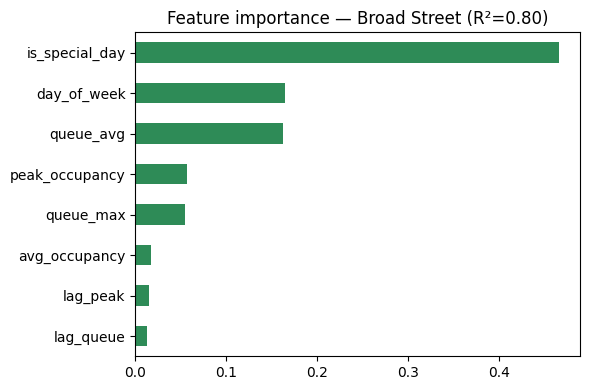

In [25]:
best_lot = results_df.iloc[0]['lot']
importances = pd.Series(final_models[best_lot].feature_importances_, index=feature_cols).sort_values(ascending=False)

importances.head(8).plot(kind='barh', figsize=(6,4), color='seagreen')
plt.title(f'Feature importance — {best_lot} (R²={results_df.iloc[0]["r2"]:.2f})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Part D  Haversine-Based Rerouting

When a lot exceeds 90% occupancy, find nearby lots (within 1 km, using great-circle Haversine distance) with spare capacity (<75% occupied) to suggest as alternatives.

In [26]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    R = 6371.0
    p1, p2 = radians(lat1), radians(lat2)
    dphi, dlambda = radians(lat2 - lat1), radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

lot_locs = daily.groupby('SystemCodeNumber')[['lat','lon']].first()
lots = lot_locs.index.tolist()
dist_matrix = pd.DataFrame(
    [[haversine(lot_locs.loc[a,'lat'], lot_locs.loc[a,'lon'], lot_locs.loc[b,'lat'], lot_locs.loc[b,'lon']) for b in lots] for a in lots],
    index=lots, columns=lots
)
dist_matrix.round(2)

,BHMBCCMKT01,BHMBCCTHL01,BHMEURBRD01,BHMMBMMBX01,BHMNCPHST01,BHMNCPNST01,Broad Street,Others-CCCPS105a,Others-CCCPS119a,Others-CCCPS135a,Others-CCCPS202,Others-CCCPS8,Others-CCCPS98,Shopping
BHMBCCMKT01,0.00,0.01,0.60,1561.11,0.72,0.72,0.88,0.87,0.88,0.88,0.88,0.88,0.88,0.71
BHMBCCTHL01,0.01,0.00,0.60,1561.11,0.72,0.72,0.87,0.88,0.89,0.88,0.88,0.89,0.89,0.72
BHMEURBRD01,0.60,0.60,0.00,1561.61,1.31,1.31,1.24,1.16,1.16,1.16,1.16,1.16,1.16,0.62
BHMMBMMBX01,1561.11,1561.11,1561.61,0.00,1560.44,1560.44,1561.27,1560.49,1560.49,1560.49,1560.49,1560.49,1560.49,1561.13
BHMNCPHST01,0.72,0.72,1.31,1560.44,0.00,0.00,1.02,0.88,0.89,0.88,0.88,0.89,0.89,1.19
BHMNCPNST01,0.72,0.72,1.31,1560.44,0.00,0.00,1.03,0.88,0.89,0.88,0.88,0.89,0.88,1.19
Broad Street,0.88,0.87,1.24,1561.27,1.02,1.03,0.00,1.67,1.68,1.68,1.68,1.68,1.68,1.58
Others-CCCPS105a,0.87,0.88,1.16,1560.49,0.88,0.88,1.67,0.00,0.01,0.01,0.01,0.01,0.01,0.64
Others-CCCPS119a,0.88,0.89,1.16,1560.49,0.89,0.89,1.68,0.01,0.00,0.01,0.01,0.00,0.00,0.65
Others-CCCPS135a,0.88,0.88,1.16,1560.49,0.88,0.88,1.68,0.01,0.01,0.00,0.00,0.01,0.00,0.64


In [27]:
alerts = []
for date, grp in daily.groupby('Date'):
    occ_by_lot = grp.set_index('SystemCodeNumber')['occupancy_rate'].to_dict()
    for lot, rate in occ_by_lot.items():
        if rate > 0.9:
            candidates = dist_matrix.loc[lot]
            nearby = candidates[(candidates > 0) & (candidates <= 1.0)]
            alts = [(alt, occ_by_lot.get(alt, 1.0)) for alt in nearby.index if occ_by_lot.get(alt, 1.0) < 0.75]
            alerts.append({
                'date': date, 'lot': lot, 'occupancy_rate': round(rate, 3),
                'num_alternatives': len(alts),
                'best_alternative': min(alts, key=lambda x: x[1])[0] if alts else None
            })

alerts_df = pd.DataFrame(alerts)
print(f"Total rerouting alerts generated: {len(alerts_df)}")
print(f"Alerts with a viable alternative found: {(alerts_df['num_alternatives'] > 0).sum()}")
alerts_df.head(10)

Total rerouting alerts generated: 154
Alerts with a viable alternative found: 122


,date,lot,occupancy_rate,num_alternatives,best_alternative
0,2016-10-04,BHMEURBRD01,0.987,1,BHMBCCMKT01
1,2016-10-04,BHMMBMMBX01,0.948,0,NaN
2,2016-10-04,Broad Street,0.990,1,BHMBCCMKT01
3,2016-10-05,BHMEURBRD01,0.968,1,BHMBCCMKT01
4,2016-10-05,BHMMBMMBX01,0.965,0,NaN
5,2016-10-05,Broad Street,0.970,1,BHMBCCMKT01
6,2016-10-06,BHMEURBRD01,0.989,2,BHMBCCMKT01
7,2016-10-06,BHMMBMMBX01,0.959,0,NaN
8,2016-10-06,Broad Street,0.986,1,BHMBCCMKT01
9,2016-10-07,BHMMBMMBX01,0.971,0,NaN


---
## Part E  Hybrid Pricing System (ML + Rules) and Final Dashboard

For each lot: if its XGBoost model is reliable (R² > 0.4), use its *predicted* next-day occupancy rate to set price. Otherwise, fall back to the current occupancy rate with the same surge/discount rule from Model 3.

In [28]:
base_price, min_price, max_price = 10.0, 5.0, 20.0
surge_factor, discount_factor = 1.5, 0.8
threshold_high, threshold_low = 0.8, 0.3

def occ_rate_to_price(rate, is_special):
    mult = surge_factor if rate > threshold_high else (discount_factor if rate < threshold_low else 1.0)
    price = base_price * mult * (1.2 if is_special else 1.0)
    return float(max(min_price, min(price, max_price)))

hybrid_rows = []
for lot, grp in daily.groupby('SystemCodeNumber'):
    grp = grp.dropna(subset=feature_cols).sort_values('Date')
    if lot in final_models:
        preds = final_models[lot].predict(grp[feature_cols])
        pred_rate = np.clip(preds / grp['capacity'].values, 0, 2)
        method = 'XGBoost'
    else:
        pred_rate = grp['occupancy_rate'].values
        method = 'Rule-based'
    prices = [occ_rate_to_price(r, s) for r, s in zip(pred_rate, grp['is_special_day'])]
    for date, rate, price in zip(grp['Date'], pred_rate, prices):
        hybrid_rows.append({'lot': lot, 'date': date, 'predicted_occ_rate': rate, 'price': price, 'method': method})

hybrid_df = pd.DataFrame(hybrid_rows)
hybrid_df.groupby('method')['lot'].nunique()

method
XGBoost    14
Name: lot, dtype: int64

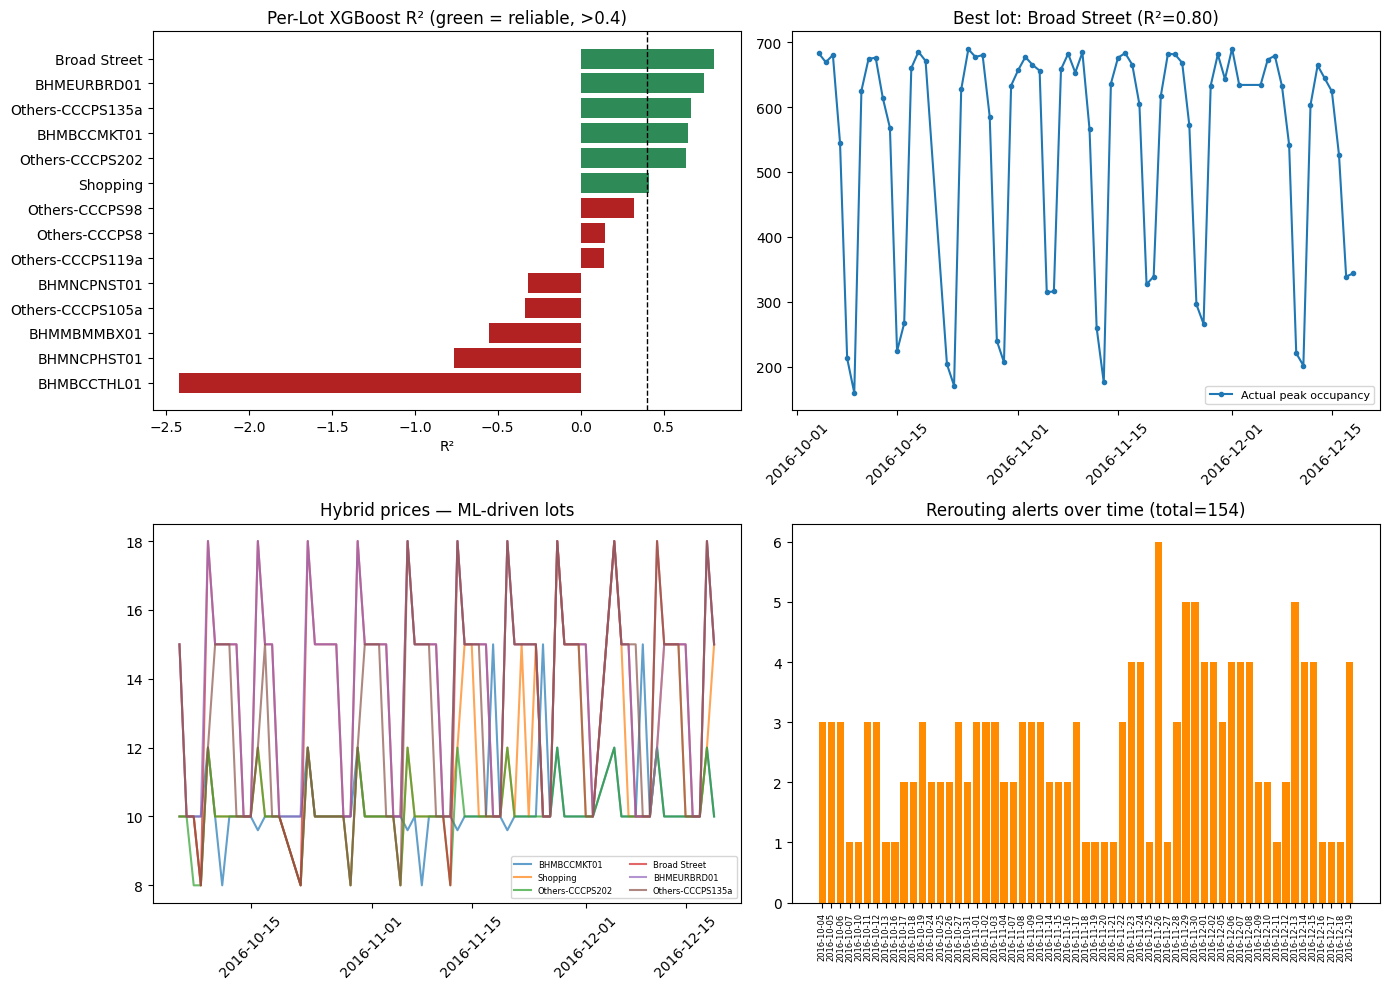

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
plot_df = results_df.sort_values('r2')
colors = ['firebrick' if r <= 0.4 else 'seagreen' for r in plot_df['r2']]
ax.barh(plot_df['lot'], plot_df['r2'], color=colors)
ax.axvline(0.4, color='black', linestyle='--', linewidth=1)
ax.set_title('Per-Lot XGBoost R² (green = reliable, >0.4)')
ax.set_xlabel('R²')

ax = axes[0,1]
best = daily[daily['SystemCodeNumber']==best_lot].dropna(subset=['target_next_peak'])
ax.plot(best['Date'], best['peak_occupancy'], label='Actual peak occupancy', marker='o', markersize=3)
ax.set_title(f'Best lot: {best_lot} (R²={results_df.iloc[0]["r2"]:.2f})')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)

ax = axes[1,0]
for lot in list(reliable_lots)[:6]:
    sub = hybrid_df[hybrid_df['lot']==lot]
    ax.plot(sub['date'], sub['price'], label=lot, alpha=0.7)
ax.set_title('Hybrid prices — ML-driven lots')
ax.legend(fontsize=6, ncol=2)
ax.tick_params(axis='x', rotation=45)

ax = axes[1,1]
alerts_by_date = alerts_df.groupby('date').size()
ax.bar(alerts_by_date.index.astype(str), alerts_by_date.values, color='darkorange')
ax.set_title(f'Rerouting alerts over time (total={len(alerts_df)})')
ax.tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()

## Summary

- **Streaming layer (Pathway):** 4 rule-based pricing models running on daily tumbling windows across all 14 lots.
- **Forecasting layer (XGBoost):** per-lot models beat a single pooled model, but only reliably explain demand for 6 of 14 lots 
- **Geolocation layer (Haversine):** real distance-based rerouting, including catching a bad-coordinate lot in the raw data.
- **Final system:** a hybrid — ML pricing where it's trustworthy, transparent rule-based pricing where it isn't.